# 04 — Multitask Model Training

Train the MTL model with shared backbone and three task heads using uncertainty-weighted masked loss.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import joblib

from src.data.dataset import AsteroidDataset
from src.models.mtl_model import AsteroidMTLModel
from src.models.losses import MultiTaskLoss
from src.training.trainer import Trainer
from src.utils.visualization import plot_training_history

%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## 1. Load Data

In [2]:
train_ds = AsteroidDataset('../data/processed/train.parquet')
val_ds = AsteroidDataset('../data/processed/val.parquet')
test_ds = AsteroidDataset('../data/processed/test.parquet')

print(f'Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}')
print(f'Features: {train_ds.n_features}')

train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=2048, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=2048, shuffle=False, num_workers=2)

Train: 670961, Val: 143778, Test: 143778
Features: 35


## 2. Compute Class Weights

In [3]:
label_encoder = joblib.load('../data/processed/label_encoder.joblib')
n_classes = len(label_encoder.classes_)

# Inverse frequency class weights
train_df = pd.read_parquet('../data/processed/train.parquet')
class_counts = train_df['class_label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * n_classes
class_weights = torch.FloatTensor(class_weights)

print('Classes:', label_encoder.classes_)
print('Weights:', class_weights.numpy().round(3))

Classes: ['AMO' 'APO' 'ATE' 'IMB' 'MBA' 'MCA' 'OMB' 'Rare' 'TJN' 'TNO']
Weights: [3.960e-01 2.640e-01 1.938e+00 1.650e-01 4.000e-03 1.790e-01 1.180e-01
 5.561e+00 4.080e-01 9.670e-01]


## 3. Initialize Model

In [4]:
model = AsteroidMTLModel(
    n_features=train_ds.n_features,
    n_classes=n_classes,
    backbone_layers=[512, 256, 128, 64],
    backbone_dropouts=[0.3, 0.3, 0.2, 0.2],
    head_hidden=32,
    head_dropout=0.1,
)

criterion = MultiTaskLoss(n_classes=n_classes, class_weights=class_weights)

all_params = list(model.parameters()) + list(criterion.parameters())
optimizer = torch.optim.AdamW(all_params, lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 201,581
AsteroidMTLModel(
  (backbone): SharedBackbone(
    (network): Sequential(
      (0): Linear(in_features=35, out_features=512, bias=True)
      (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=512, out_features=256, bias=True)
      (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.3, inplace=False)
      (8): Linear(in_features=256, out_features=128, bias=True)
      (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.2, inplace=False)
      (12): Linear(in_features=128, out_features=64, bias=True)
      (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (14): ReLU()
      (15): Dropout(p=0.2, inplace=False)
    )
  )
  (class_head): TaskHead(


## 4. Train

In [5]:
trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    max_grad_norm=1.0,
    checkpoint_dir='../models',
)

history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    patience=10,
)

Epoch   1 | Train Loss: 11.4165 | Val Loss: 0.1413 | Val Acc: 0.7511 | Val H R²: 0.8526 | Val Diam R²: 0.6783 | Val Alb R²: 0.3635
Epoch   2 | Train Loss: 0.7482 | Val Loss: -0.2184 | Val Acc: 0.9011 | Val H R²: 0.8768 | Val Diam R²: 0.6837 | Val Alb R²: 0.3989
Epoch   3 | Train Loss: 0.3768 | Val Loss: -0.4560 | Val Acc: 0.9087 | Val H R²: 0.8857 | Val Diam R²: 0.7481 | Val Alb R²: 0.4166
Epoch   4 | Train Loss: 0.1118 | Val Loss: -0.7411 | Val Acc: 0.9433 | Val H R²: 0.8940 | Val Diam R²: 0.7543 | Val Alb R²: 0.4022
Epoch   5 | Train Loss: -0.0744 | Val Loss: -0.7983 | Val Acc: 0.9415 | Val H R²: 0.8965 | Val Diam R²: 0.7413 | Val Alb R²: 0.4259
Epoch   6 | Train Loss: -0.1546 | Val Loss: -0.9233 | Val Acc: 0.9458 | Val H R²: 0.8967 | Val Diam R²: 0.7654 | Val Alb R²: 0.4274
Epoch   7 | Train Loss: -0.2456 | Val Loss: -0.9116 | Val Acc: 0.9522 | Val H R²: 0.9040 | Val Diam R²: 0.7662 | Val Alb R²: 0.4270
Epoch   8 | Train Loss: -0.2945 | Val Loss: -0.9604 | Val Acc: 0.9474 | Val H R²

## 5. Training Curves

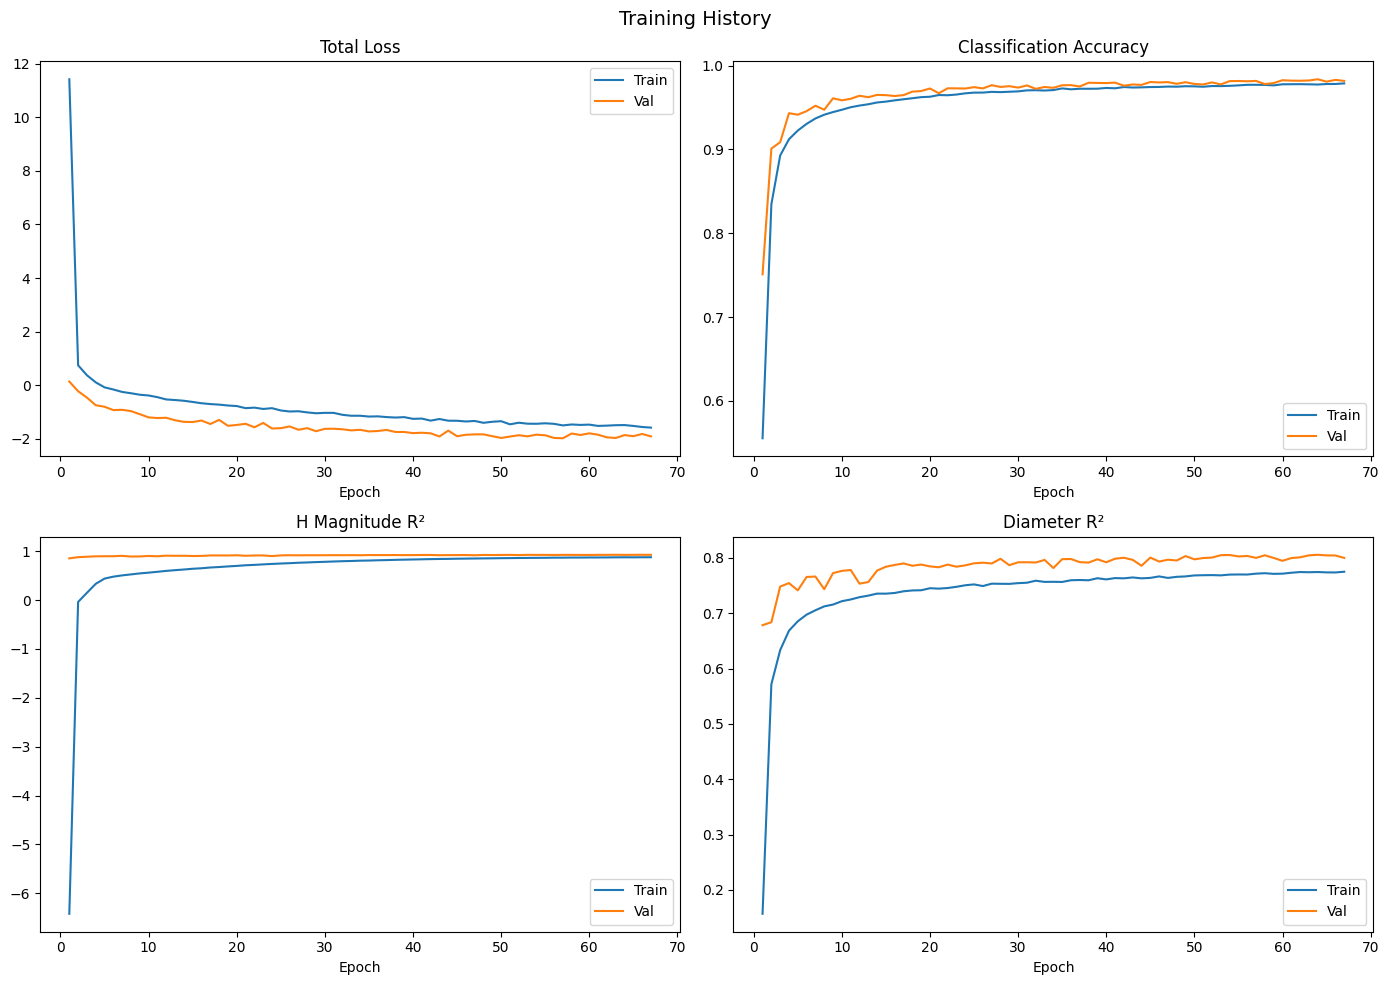

In [6]:
fig = plot_training_history(history)
plt.show()


=== Learned Uncertainty Weights ===
sigma_class: 0.2297
sigma_h:     0.6304
sigma_diam:  0.2474


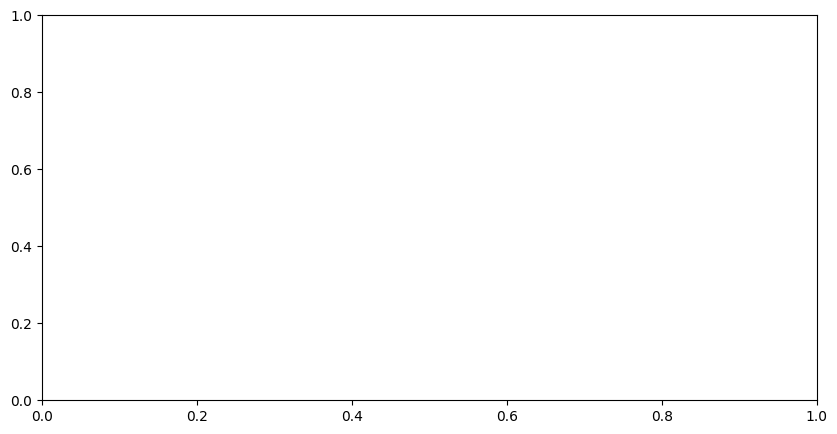

In [7]:
# Learned uncertainty weights over training
# (these are logged during training via the loss metrics)
fig, ax = plt.subplots(figsize=(10, 5))
epochs = [h['epoch'] for h in history]

# Extract sigma values from the criterion's state at each checkpoint
# For now, show the final learned values
print('\n=== Learned Uncertainty Weights ===')
print(f'sigma_class: {torch.exp(criterion.log_sigma_class).item():.4f}')
print(f'sigma_h:     {torch.exp(criterion.log_sigma_h).item():.4f}')
print(f'sigma_diam:  {torch.exp(criterion.log_sigma_diam).item():.4f}')

## 6. Evaluate on Test Set

In [8]:
# Load best checkpoint
trainer.load_checkpoint('best_mtl_model.pt')
test_metrics = trainer.validate(test_loader)

print('=== Test Set Results ===')
print(f'\nClassification:')
print(f'  Accuracy:    {test_metrics["class_accuracy"]:.4f}')
print(f'  F1 (macro):  {test_metrics["class_f1_macro"]:.4f}')
print(f'  F1 (weight): {test_metrics["class_f1_weighted"]:.4f}')
print(f'\nH Magnitude Regression:')
print(f'  MAE:  {test_metrics["h_mae"]:.4f}')
print(f'  RMSE: {test_metrics["h_rmse"]:.4f}')
print(f'  R²:   {test_metrics["h_r2"]:.4f}')
print(f'\nDiameter Regression (log-scale):')
print(f'  MAE:  {test_metrics["diam_mae"]:.4f}')
print(f'  RMSE: {test_metrics["diam_rmse"]:.4f}')
print(f'  R²:   {test_metrics["diam_r2"]:.4f}')

=== Test Set Results ===

Classification:
  Accuracy:    0.9817
  F1 (macro):  0.9405
  F1 (weight): 0.9828

H Magnitude Regression:
  MAE:  0.3597
  RMSE: 0.4964
  R²:   0.9237

Diameter Regression (log-scale):
  MAE:  0.1779
  RMSE: 0.2385
  R²:   0.7939
